In [48]:
try:
    import yfinance, pypfopt, dataframe_image
except ImportError:
    %pip install -U yfinance PyPortfolioOpt -q
    %pip install dataframe_image -q

import dataframe_image as dfi
import pandas as pd
import numpy as np
import yfinance as yf
import pathlib

from pandas_datareader.data import DataReader
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import KernelDensity

from scipy.optimize import minimize
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster


from numpy.linalg import eigh

import plotly.express as px
import matplotlib.pyplot as plt
from pypfopt import plotting

import cvxpy as cp


# Helper Functions

## General Functions

In [2]:
# ------------------------------------------------------------------------------------
# Helper to download or load cached prices
# ------------------------------------------------------------------------------------
def get_prices(tickers, start, end, tag):
    p_path = CACHE_DIR / f"prices_{tag}_{start}_{end}.parquet"
    if p_path.exists():
        return pd.read_parquet(p_path)
    px = (
        yf.download(tickers, start=start, end=end, progress=False)["Close"]
          .dropna(axis=1, how='all')
    )
    px.to_parquet(p_path)
    return px


def save_df_as_image(df, filename='filtered_weights.png', dpi=200):
    fig, ax = plt.subplots(figsize=(len(df.columns)*2, len(df)*0.5 + 1))
    ax.axis('off')
    table = ax.table(cellText=df.round(4).values,
                     colLabels=df.columns,
                     rowLabels=df.index,
                     cellLoc='center',
                     loc='center')
    table.scale(1, 1.5)
    plt.tight_layout()
    plt.savefig(filename, dpi=dpi)
    plt.close()


# -------------------------------------------
# Helper functions for MVO
# -------------------------------------------
def neg_sharpe(w, mu, Σ, rf):
    port_mu  = w @ mu - rf          # daily excess return
    port_sig = np.sqrt(w @ Σ @ w)
    return - port_mu / port_sig

def mvo_weights(mu, Σ, rf, w_min=0.0, w_max=1.0):
    """Long-only max-Sharpe (SLSQP) with upper weight bound *w_max*."""
    n = len(mu)
    bounds = [(w_min, w_max)]*n
    cons   = {'type':'eq', 'fun': lambda w: w.sum() - 1}
    w0     = np.repeat(1/n, n)      # initial guess
    res = minimize(neg_sharpe, w0, args=(mu, Σ, rf),
                   method='SLSQP', bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(res.message)
    return res.x


# ================================================================
# Evaluate in-sample (train) and out-of-sample (test) performance
# ================================================================

def portfolio_returns(weights, returns_test_subset):
    """Compute cumulative returns for a given weight vector and matching test returns"""
    port_ret = returns_test_subset @ weights
    cumulative = (1 + port_ret).cumprod()
    return cumulative



# def portfolio_stats(w, rets, rf_daily):
#     """Return μ, σ, Sharpe (all annualised) plus total return."""

#     # Convert weights to numpy
#     if isinstance(w, (pd.Series, pd.DataFrame)):
#         w = w.values
#     # Convert returns to numpy
#     if isinstance(rets, pd.DataFrame):
#         rets = rets.values
#     # Convert rf_daily to numpy
#     if isinstance(rf_daily, (pd.Series, pd.DataFrame)):
#         rf_daily = rf_daily.values

#     # Ensure rf_daily is (n_days, 1) for broadcasting
#     if rf_daily.ndim == 1:
#         rf_daily = rf_daily.reshape(-1, 1)

#     # Calculate excess returns (broadcasts risk-free rate for each day across all assets)
#     excess = rets - rf_daily  # shape (n_days, n_assets)
#     port_excess = excess @ w  # shape (n_days,)
#     port_total  = rets @ w    # shape (n_days,)

#     mu  = port_excess.mean() * 252
#     sig = port_total.std() * np.sqrt(252)
#     sharpe = mu / sig
#     tot_ret = (1 + port_total).prod() - 1

#     return pd.Series([mu, sig, sharpe, tot_ret],
#                      index=['μ_ann','σ_ann','Sharpe','TotalReturn'])

def portfolio_stats(w, rets, rf_daily):
    """Return μ, σ, Sharpe (all annualised) plus total return."""
    excess = rets.sub(rf_daily, axis=0)
    port_excess = excess @ w
    port_total  = rets @ w
    mu  = port_excess.mean()*252
    sig = port_total.std()*np.sqrt(252)
    sharpe = mu / sig
    tot_ret = (1 + port_total).prod() - 1
    return pd.Series([mu, sig, sharpe, tot_ret],
                     index=['μ_ann','σ_ann','Sharpe','TotalReturn'])
def contrib_to_risk(w, Σ):
    """% contribution of each asset to portfolio variance."""
    if isinstance(w, (pd.Series, pd.DataFrame)):
        idx = w.index
        w = w.values
    else:
        idx = None
    if isinstance(Σ, pd.DataFrame):
        Σ = Σ.values

    w = w.flatten()  # ensure 1D
    port_var = w.T @ Σ @ w
    mrc      = Σ @ w
    rc       = w * mrc
    pct_rc   = rc / port_var

    if idx is not None:
        return pd.Series(pct_rc, index=idx)
    return pct_rc.sort_values()


def max_drawdown(cumulative_returns):
    """Calculate maximum drawdown from cumulative return series"""
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()  # most negative drawdown

def compute_drawdown_curve(cumulative_returns):
    """Return the drawdown curve: percentage drop from peak"""
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown


## Kelly Optimization

In [3]:


# def kelly_long_only_fully_invested(mu: pd.Series, Sigma: pd.DataFrame, rf: float) -> pd.Series:
#     """
#     Solve the Kelly criterion with long-only and full-investment constraints using convex optimization.

#     Parameters:
#         mu (pd.Series): Expected returns (daily).
#         Sigma (pd.DataFrame): Covariance matrix of returns.
#         rf (float): Daily risk-free rate.

#     Returns:
#         pd.Series: Optimal Kelly weights (long-only, fully invested).
#     """
#     # Convert to numpy
#     if isinstance(mu, pd.Series):
#         mu_vec = mu.values
    
#     else:
#         mu_vec = mu
    
#     if isinstance(Sigma, pd.DataFrame):
#         Sigma_mat = Sigma.values
    
#     else:
#         Sigma_mat = Sigma
    
    
#     excess_mu = mu_vec - rf

#     n = len(mu)
#     w = cp.Variable(n)

#     # Objective: maximize log-growth
#     objective = cp.Maximize(excess_mu @ w - 0.5 * cp.quad_form(w, Sigma_mat))

#     # Constraints
#     constraints = [
#         w >= 0,         # long-only
#         cp.sum(w) == 1  # fully invested
#     ]

#     # Solve problem
#     prob = cp.Problem(objective, constraints)
#     prob.solve()

#     if w.value is None:
#         raise ValueError("Optimization failed.")

#     # Convert to pandas Series
#     weights = pd.Series(w.value, index=mu.index)
#     return weights.round(4)



def kelly_long_only_fully_invested(
    mu: pd.Series, Sigma: pd.DataFrame, rf: float, 
    w_min=0.0, w_max=1.0
) -> pd.Series:
    """
    Kelly criterion with long-only, fully-invested, and bounds constraints.

    Parameters:
        mu (pd.Series): Expected returns (daily).
        Sigma (pd.DataFrame): Covariance matrix.
        rf (float): Risk-free rate.
        w_min (float or array-like): Lower bounds for weights.
        w_max (float or array-like): Upper bounds for weights.

    Returns:
        pd.Series: Optimal Kelly weights.
    """
    mu_vec = mu.values if isinstance(mu, pd.Series) else mu
    Sigma_mat = Sigma.values if isinstance(Sigma, pd.DataFrame) else Sigma
    n = len(mu_vec)
    w = cp.Variable(n)
    excess_mu = mu_vec - rf

    # Convert bounds to arrays if needed
    w_min_arr = np.full(n, w_min) if np.isscalar(w_min) else np.asarray(w_min)
    w_max_arr = np.full(n, w_max) if np.isscalar(w_max) else np.asarray(w_max)

    objective = cp.Maximize(excess_mu @ w - 0.5 * cp.quad_form(w, Sigma_mat))
    constraints = [
        w >= w_min_arr,
        w <= w_max_arr,
        cp.sum(w) == 1
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    if w.value is None:
        raise ValueError("Optimization failed.")

    return pd.Series(w.value, index=mu.index).round(6)



## Clustering

In [4]:
def getQuasiDiag(link):
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0]*2, 2)
        df0 = sortIx[sortIx >= numItems]
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i + 1)
        sortIx = pd.concat([sortIx, df1]).sort_index()
        sortIx.index = range(sortIx.shape[0])
    return sortIx.tolist()

def getClusterVar(cov, cluster_items):
    cov_slice = cov[np.ix_(cluster_items, cluster_items)]
    weights = np.repeat(1.0/len(cluster_items), len(cluster_items))
    variance = np.dot(weights, np.dot(cov_slice, weights))
    return variance

def getRecBipart(cov, sortIx):
    w = pd.Series(1.0, index=sortIx)
    cItems = [sortIx]
    while len(cItems) > 0:
        cItems = [i[j:k] for i in cItems for j, k in (
            (0, len(i)//2), (len(i)//2, len(i))
        ) if len(i) > 1]
        for i in range(0, len(cItems), 2):
            cItems0 = cItems[i]
            cItems1 = cItems[i+1]
            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)
            alpha = 1 - cVar0 / (cVar0 + cVar1)
            w[cItems0] *= alpha
            w[cItems1] *= 1 - alpha
    return w


def plot_dendrogram(corr_matrix, title):
    # Convert correlation to distance matrix
    distance_matrix = 1 - corr_matrix
    # Ensure symmetric with zeros on diagonal
    np.fill_diagonal(distance_matrix.values, 0)
    # Condense distance matrix (input to linkage)
    condensed_distance = squareform(distance_matrix.values)
    # Linkage for clustering
    linkage = sch.linkage(condensed_distance, method='ward')
    # Plot dendrogram
    plt.figure(figsize=(12, 6))
    sch.dendrogram(linkage, labels=corr_matrix.columns, leaf_rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Denoising

In [5]:
def mpPDF(var, q, pts):
    eMin, eMax = var*(1-(1./q)**.5)**2, var*(1+(1./q)**.5)**2 # calc lambda_minus, lambda_plus
    eVal = np.linspace(eMin, eMax, pts) #Return evenly spaced numbers over a specified interval. eVal='lambda'
    #Note: 1.0/2*2 = 1.0 not 0.25=1.0/(2*2)
    pdf = q/(2*np.pi*var*eVal)*((eMax-eVal)*(eVal-eMin))**.5 #np.allclose(np.flip((eMax-eVal)), (eVal-eMin))==True
    pdf = pd.Series(pdf, index=eVal)
    return pdf

#snippet 2.2
#Test Marcenko-Pastur Thm
def getPCA(matrix):
    # Get eVal, eVec from a Hermitian matrix
    eVal, eVec = np.linalg.eigh(matrix) #complex Hermitian (conjugate symmetric) or a real symmetric matrix.
    indices = eVal.argsort()[::-1] #arguments for sorting eval desc
    eVal,eVec = eVal[indices],eVec[:,indices]
    eVal = np.diagflat(eVal) # identity matrix with eigenvalues as diagonal
    return eVal,eVec


def findMaxEval(eVal, q, bWidth):
    out = minimize(lambda *x: errPDFs(*x), x0=np.array(0.5), args=(eVal, q, bWidth), bounds=((1E-5, 1-1E-5),))
    print("found errPDFs"+str(out['x'][0]))
    if out['success']: var = out['x'][0]
    else: var=1
    eMax = var*(1+(1./q)**.5)**2
    return eMax, var
    
# code snippet 2.5 - denoising by constant residual eigenvalue
# Remove noise from corr by fixing random eigenvalue
# Operation invariante to trace(Correlation)
# The Trace of a square matrix is the _Sum_ of its eigenvalues
# The Determinate of thematrix is the _Product_ of its eigenvalues
def denoisedCorr(eVal, eVec, nFacts):
    eVal_ = np.diag(eVal).copy()
    eVal_[nFacts:] = eVal_[nFacts:].sum()/float(eVal_.shape[0] - nFacts) #all but 0..i values equals (1/N-i)sum(eVal_[i..N]))
    eVal_ = np.diag(eVal_) #square matrix with eigenvalues as diagonal: eVal_.I
    corr1 = np.dot(eVec, eVal_).dot(eVec.T) #Eigendecomposition of a symmetric matrix: S = QΛQT
    corr1 = (corr1 + corr1.T) / 2  # Enforce symmetry!
    corr1 = cov2corr(corr1) # Rescaling the correlation matrix to have 1s on the main diagonal
    return corr1

# def cov2corr(cov):
#     # Derive the correlation matrix from a covariance matrix
#     std = np.sqrt(np.diag(cov))
#     corr = cov/np.outer(std,std)
#     corr[corr<-1], corr[corr>1] = -1,1 #for numerical errors
#     return corr

def cov2corr(cov):
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    np.fill_diagonal(corr, 1.0)  # Ensure the diagonal is exactly 1
    return corr
    
def corr2cov(corr, std):
    cov = corr * np.outer(std, std)
    return cov     


def errPDFs(var, eVal, q, bWidth, pts=1000):
    var = var[0]
    pdf0 = mpPDF(var, q, pts) #theoretical pdf
    pdf1 = fitKDE(eVal, bWidth, x=pdf0.index.values) #empirical pdf
    sse = np.sum((pdf1-pdf0)**2)
    print("sse:"+str(sse))
    return sse 


def fitKDE(obs, bWidth=.15, kernel='gaussian', x=None):
    #Fit kernel to a series of obs, and derive the prob of obs
    # x is the array of values on which the fit KDE will be evaluated
    #print(len(obs.shape) == 1)
    if len(obs.shape) == 1: obs = obs.reshape(-1,1)
    kde = KernelDensity(kernel = kernel, bandwidth = bWidth).fit(obs)
    #print(x is None)
    if x is None: x = np.unique(obs).reshape(-1,1)
    #print(len(x.shape))
    if len(x.shape) == 1: x = x.reshape(-1,1)
    logProb = kde.score_samples(x) # log(density)
    pdf = pd.Series(np.exp(logProb), index=x.flatten())
    return pdf
    

# Step 1: Computing the Previous Results

## Data Collection

In [6]:
TRAIN_START, TRAIN_END = "2023-01-01", "2025-04-30"
TEST_START,  TEST_END  = "2025-05-01", "2025-06-01"
TRADING_DAYS     = 252
CACHE_DIR        = pathlib.Path("data_cache"); CACHE_DIR.mkdir(exist_ok=True)

# ---- universe --------------------------------------------------------------------
TICKERS = [
    # Materials
    "LIN", "APD", "ALB",
    # Communication Services
    "META", "CMCSA", "FOXA", "GOOGL",
    # Energy
    "XOM", "COP", "APA", 'CVX',
    # Financials
    "JPM", "PNC", "LNC", "BRK-B", 'V',
    # Industrials
    "CAT", "UPS", "CARR", 'GE',
    # Information Technology
    "NVDA", "SNPS", "ZS", 'AAPL', 'MSFT',
    # Consumer Staples
    "PG", "KMB", "TAP", 'COST',
    # Utilities
    "NEE", "DUK", "AES",
    # Health Care
    "UNH", "MDT", "BAX", 'LLY',
    # Consumer Discretionary
    "AMZN", "NKE", "ETSY", "TSLA",
    # Real Estate
    "PLD", "AMT", "AVB",
]

EXTRA_ASSETS = ["GC=F", "BTC-USD"]
TICKERS      = TICKERS + EXTRA_ASSETS


In [7]:
# ------------------------------------------------------------------------------------
# Fetch training & test windows
# ------------------------------------------------------------------------------------

prices_train = get_prices(TICKERS, TRAIN_START, TRAIN_END, "train").dropna(axis=0, how='any')
prices_test  = get_prices(TICKERS, TEST_START,  TEST_END,  "test").dropna(axis=0, how='any')


# Convert to log-returns (drop first row)
returns_train = np.log(prices_train / prices_train.shift()).dropna()
returns_test  = np.log(prices_test  / prices_test.shift()).dropna()

# Calculate mean returns and covariance matrix
mean_returns_train = returns_train.mean()
mean_returns_test  = returns_test.mean()

# ================================================================
# Risk-free daily series from FRED (DGS2)
# ================================================================
rf_all = (
    DataReader("DGS2", "fred", TRAIN_START, TEST_END)   # % p.a.
      .div(100.0)                                       # to decimal p.a.
      .ffill()                                          # fill Fed/market holidays
)

rf_daily_train = (
    rf_all["DGS2"]
    .reindex(returns_train.index, method="ffill")
    / TRADING_DAYS
)
rf_daily_test = (
    rf_all["DGS2"]
    .reindex(returns_test.index, method="ffill")
    / TRADING_DAYS
)


rf_mean_train = rf_daily_train.mean()
rf_mean_test  = rf_daily_test.mean()


## Visualization

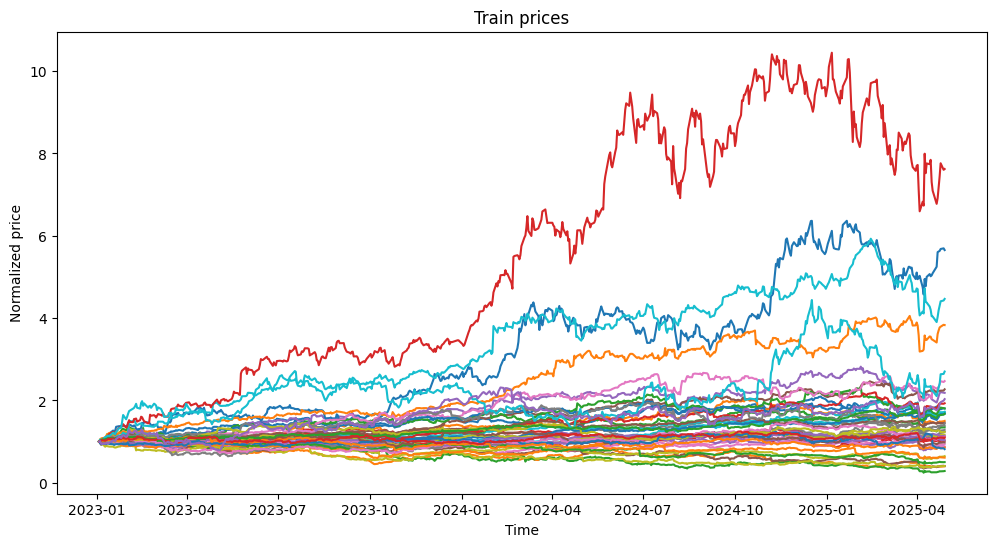

In [8]:
# plot the normalized prices_train and prices_test

prices_train_norm = prices_train / prices_train.iloc[0]
prices_test_norm = prices_test / prices_test.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(prices_train_norm)
plt.title('Train prices')
plt.xlabel('Time')
plt.ylabel('Normalized price')
#plt.legend(prices_train_norm.columns)
plt.show()
# px.line(prices_test_norm, title='Test prices').show()


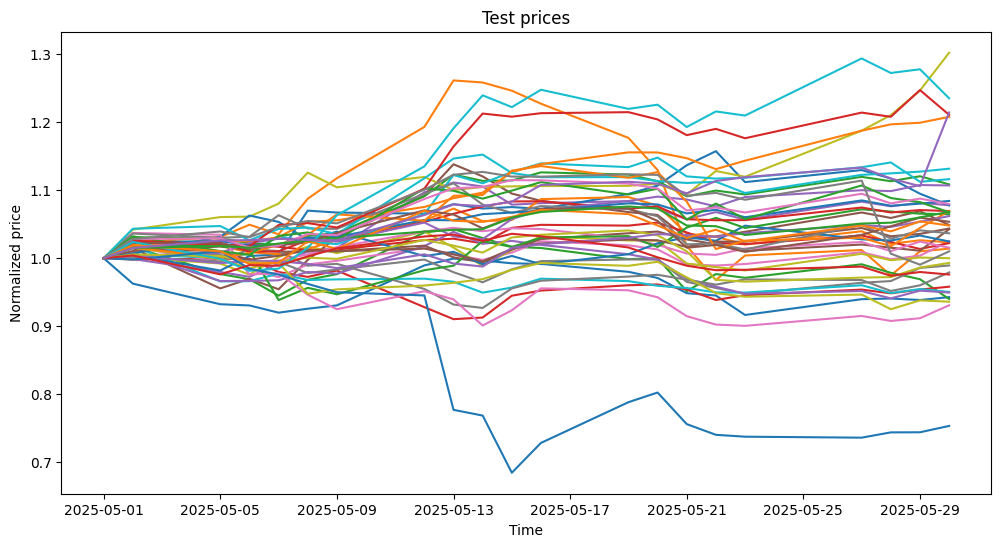

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(prices_test_norm)
plt.title('Test prices')
plt.xlabel('Time')
plt.ylabel('Normalized price')
#plt.legend(prices_train_norm.columns)
plt.show()

## Portfolio Optimization using Sample Covariance Matrix

### Sample covariance matrix estimation

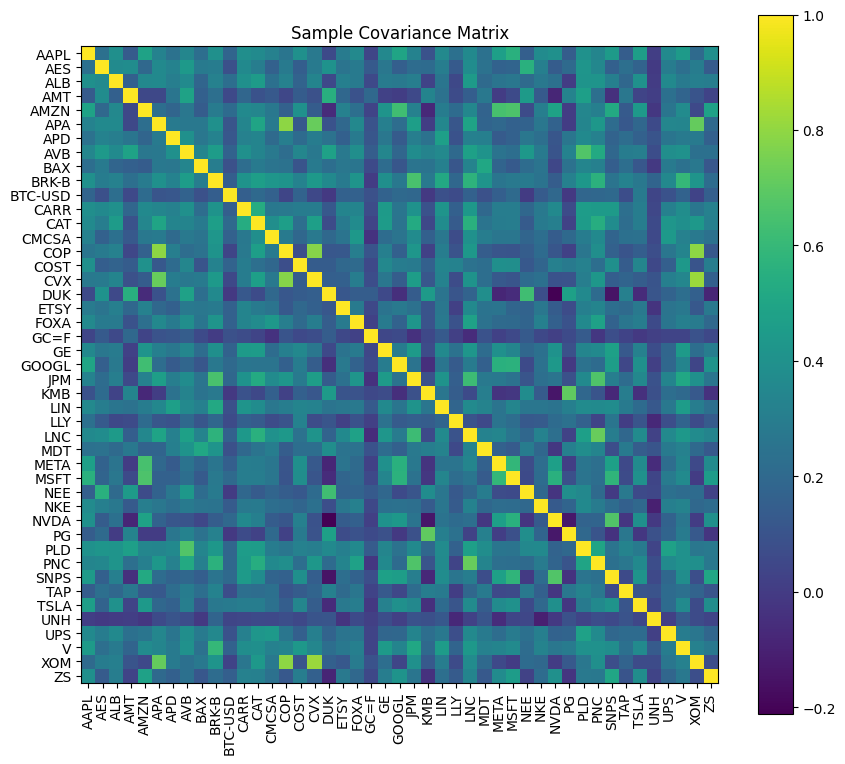

In [10]:
# ---------- (1) sample covariance ---------------------------------
Sigma_sample = returns_train.cov(ddof=1)

ax = plotting.plot_covariance(Sigma_sample, plot_correlation=True)
ax.figure.set_size_inches(9, 9)
ax.set_title("Sample Covariance Matrix")
plt.show()

### Mean-Variance Optimization

In [11]:
num_assets = len(TICKERS)
w_min = 0.0 # no short selling
w_max = 0.35

initial_weights = np.ones(num_assets) / num_assets

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

w_mvo_sample = mvo_weights(mean_returns_train, Sigma_sample, rf_mean_train, w_min, w_max)
w_mvo_sample   = pd.Series(w_mvo_sample.round(3), index=TICKERS,
                             name='Sample')


w_mvo_sample = pd.Series(w_mvo_sample, index=TICKERS, name='Sample')

df_w_mvo_sample = w_mvo_sample[(w_mvo_sample > 0)]
display(df_w_mvo_sample.to_frame("MVO (Sample)").round(3))


,MVO (Sample)
APA,0.098
CVX,0.081
V,0.101
UPS,0.056
NVDA,0.350
SNPS,0.135
KMB,0.061
NEE,0.062
MDT,0.056


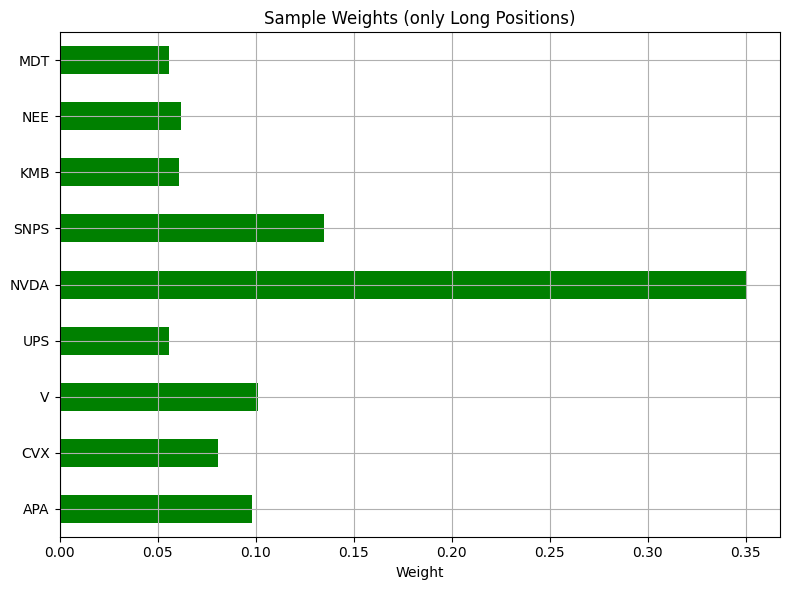

In [12]:
# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
df_w_mvo_sample.plot(kind='barh', color=['green' if w > 0 else 'red' for w in df_w_mvo_sample.values])
plt.title('Sample Weights (only Long Positions)')
plt.xlabel('Weight')
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:

# ---- stats ------------------------------------------------------
stat_train_mvo_sample = portfolio_stats(w_mvo_sample,  returns_train, rf_daily_train)
stat_test_mvo_sample  = portfolio_stats(w_mvo_sample,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_mvo_sample = pd.concat({'SampleΣ': pd.concat({'Train':stat_train_mvo_sample,
                                         'Test': stat_test_mvo_sample}, axis=1)},
                   axis=1).round(3)
display(stats_mvo_sample)


Portfolio stats:


SampleΣ       
              Train   Test
μ_ann         0.254  1.138
σ_ann         0.254  0.242
Sharpe        1.000  4.710
TotalReturn   0.845  0.095

### Fully Kelly Portfolio

In [14]:
w_kelly_sample = kelly_long_only_fully_invested(mean_returns_train, Sigma_sample, rf_mean_train, w_min=w_min, w_max=w_max)
display(w_kelly_sample[w_kelly_sample > 0].sort_values(ascending=False).to_frame("Kelly (Sample)").round(3))

,Kelly (Sample)
Ticker,
BTC-USD,0.35
NVDA,0.35
META,0.30


In [15]:
stat_train_kelly_sample = portfolio_stats(w_kelly_sample, returns_train, rf_daily_train)
stat_test_kelly_sample  = portfolio_stats(w_kelly_sample, returns_test, rf_daily_test)

print('Portfolio stats:')

stats_kelly_sample = pd.concat({'Kelly': pd.concat({'Train':stat_train_kelly_sample,
                                         'Test': stat_test_kelly_sample}, axis=1)},
                   axis=1).round(3)
display(stats_kelly_sample)

Portfolio stats:


Kelly       
             Train   Test
μ_ann        0.722  1.602
σ_ann        0.347  0.258
Sharpe       2.081  6.211
TotalReturn  4.085  0.136

# Step 2: Denoising Improvements

## Ledoit–Wolf Shrinkage estimatation of covariance matrix

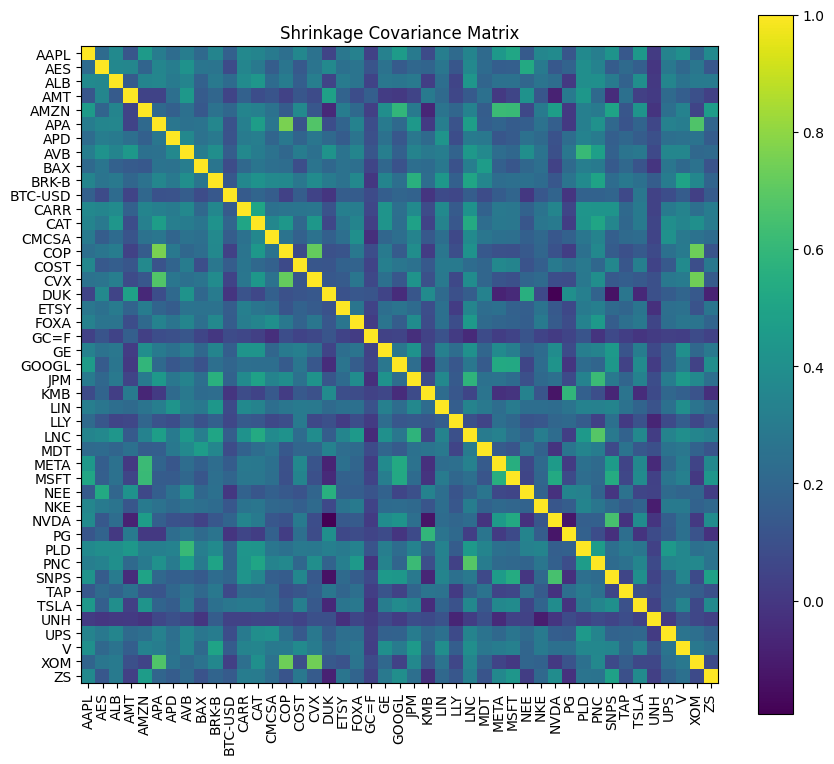

In [16]:
lw = LedoitWolf(store_precision=False, assume_centered=False)
lw.fit(returns_train.values)          

Sigma_shrinkage = pd.DataFrame(
    lw.covariance_,
    index=returns_train.columns,
    columns=returns_train.columns
)

ax = plotting.plot_covariance(Sigma_shrinkage, plot_correlation=True)
ax.figure.set_size_inches(9, 9)
ax.set_title("Shrinkage Covariance Matrix")
plt.show()

### Mean-Variance Optimization with Ledoit–Wolf Shrinkage

In [17]:
num_assets = len(TICKERS)
w_min = 0.0 # no short selling
w_max = 0.35

initial_weights = np.ones(num_assets) / num_assets

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

w_mvo_shrinkage = mvo_weights(mean_returns_train, Sigma_shrinkage, 
                                    rf_mean_train, w_min, w_max)
w_mvo_shrinkage   = pd.Series(w_mvo_shrinkage.round(3), index=TICKERS,
                             name='MVO Shrinkage')


w_mvo_shrinkage = pd.Series(w_mvo_shrinkage, index=TICKERS, name='MVO Shrinkage')

df_w_mvo_shrinkage = w_mvo_shrinkage[(w_mvo_shrinkage > 0)]
display(df_w_mvo_shrinkage.to_frame("MVO (Shrinkage)").round(3))


,MVO (Shrinkage)
APA,0.081
CVX,0.087
V,0.096
UPS,0.049
NVDA,0.350
SNPS,0.141
KMB,0.065
NEE,0.069
MDT,0.061


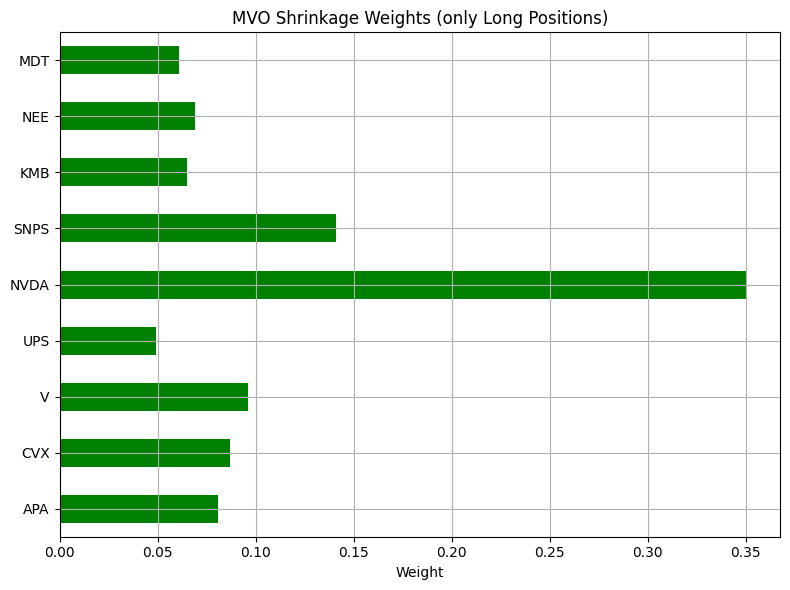

In [18]:
# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
df_w_mvo_shrinkage.plot(kind='barh', color=['green' if w > 0 else 'red' for w in df_w_mvo_shrinkage.values])
plt.title('MVO Shrinkage Weights (only Long Positions)')
plt.xlabel('Weight')
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:

# ---- stats ------------------------------------------------------
stat_train_mvo_shrinkage = portfolio_stats(w_mvo_shrinkage,  returns_train, rf_daily_train)
stat_test_mvo_shrinkage  = portfolio_stats(w_mvo_shrinkage,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_mvo_shrinkage = pd.concat({'MVO Shrinkage': pd.concat({'Train':stat_train_mvo_shrinkage,
                                         'Test': stat_test_mvo_shrinkage}, axis=1)},
                   axis=1).round(3)
display(stats_mvo_shrinkage)


Portfolio stats:


MVO Shrinkage       
                    Train   Test
μ_ann               0.261  1.132
σ_ann               0.252  0.239
Sharpe              1.037  4.736
TotalReturn         0.879  0.095

### Kelly optimization with shrinkage

In [20]:
w_kelly_shrinkage = kelly_long_only_fully_invested(mean_returns_train, Sigma_shrinkage, rf_mean_train, w_min=w_min, w_max=w_max)
display(w_kelly_shrinkage[w_kelly_shrinkage > 0].sort_values(ascending=False).to_frame("Kelly (Shrinkage)").round(3))


,Kelly (Shrinkage)
Ticker,
BTC-USD,0.35
NVDA,0.35
META,0.30


In [21]:

# ---- stats ------------------------------------------------------
stat_train_kelly_shrinkage = portfolio_stats(w_kelly_shrinkage,  returns_train, rf_daily_train)
stat_test_kelly_shrinkage  = portfolio_stats(w_kelly_shrinkage,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_kelly_shrinkage = pd.concat({'Kelly Long Only Fully Invested Shrinkage': pd.concat({'Train':stat_train_kelly_shrinkage,
                                         'Test': stat_test_kelly_shrinkage}, axis=1)},
                   axis=1).round(3)
display(stats_kelly_shrinkage)


Portfolio stats:


Kelly Long Only Fully Invested Shrinkage       
                                               Train   Test
μ_ann                                          0.722  1.602
σ_ann                                          0.347  0.258
Sharpe                                         2.081  6.211
TotalReturn                                    4.085  0.136

## MVO with Denoised Correlation (by RMT)

In [22]:
std_sample = returns_train.std().values 

# Compute eigenvalues and eigenvectors of the empirical correlation
eVal, eVec = getPCA(Sigma_sample)

# Number of time points (T) and assets (N)
T, N = returns_train.shape

# Aspect ratio q = T / N (sample size to dimension)
q = float(T) / N

# Find maximum eigenvalue for noise band
eMax, var = findMaxEval(np.diag(eVal), q, bWidth=0.01)
# Number of signal factors (eigenvalues above noise threshold)
nFacts = np.diag(eVal)[::-1].searchsorted(eMax)
nFacts = N - nFacts  # Number of eigenvalues above the threshold

# Build denoised correlation
corr_denoised = denoisedCorr(eVal, eVec, nFacts)

Sigma_denoised = corr2cov(corr_denoised, std_sample)

df_Sigma_denoised = pd.DataFrame(Sigma_denoised, index=returns_train.columns, columns=returns_train.columns)



constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0, 1)] * N  # adjust if you have other bounds

w0 = np.array([1.0 / N] * N)  # Initial guess

result = minimize(
    neg_sharpe,
    w0,
    args=(mean_returns_train.values, Sigma_denoised, rf_mean_train),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)

w_mvo_rmt = result.x

sse:3598.6277019183403
sse:3598.6275579732355
sse:899.674918887995
sse:899.6749368816738
found errPDFs0.99999


In [23]:
w_mvo_rmt_df = pd.DataFrame(w_mvo_rmt, columns=['MVO RMT'], index=TICKERS).sort_values(by='MVO RMT', ascending=False).round(3)
display(w_mvo_rmt_df[w_mvo_rmt_df['MVO RMT'] > 0.001])


,MVO RMT
NVDA,0.114
APA,0.091
V,0.089
SNPS,0.074
AVB,0.065
AAPL,0.050
NEE,0.049
KMB,0.043
PG,0.042
GE,0.038


In [24]:

# ---- stats ------------------------------------------------------
stat_train_mvo_rmt = portfolio_stats(w_mvo_rmt,  returns_train, rf_daily_train)
stat_test_mvo_rmt  = portfolio_stats(w_mvo_rmt,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_mvo_rmt = pd.concat({'MVO RMT': pd.concat({'Train':stat_train_mvo_rmt,
                                         'Test': stat_test_mvo_rmt}, axis=1)},
                   axis=1).round(3)
display(stats_mvo_rmt)

Portfolio stats:


MVO RMT       
              Train   Test
μ_ann         0.290  0.630
σ_ann         0.146  0.118
Sharpe        1.985  5.348
TotalReturn   1.106  0.054

## Kelly Long Only Fully Invested Denoised with RMT

In [25]:
w_kelly_rmt = kelly_long_only_fully_invested(mean_returns_train, Sigma_denoised, rf_mean_train, w_min=w_min, w_max=w_max)
display(w_kelly_rmt[w_kelly_rmt > 0].sort_values(ascending=False))


Ticker
BTC-USD    0.35
NVDA       0.35
META       0.30
dtype: float64

In [26]:

# ---- stats ------------------------------------------------------
stat_train_kelly_rmt = portfolio_stats(w_kelly_rmt,  returns_train, rf_daily_train)
stat_test_kelly_rmt  = portfolio_stats(w_kelly_rmt,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_kelly_rmt = pd.concat({'Kelly RMT': pd.concat({'Train':stat_train_kelly_rmt,
                                         'Test': stat_test_kelly_rmt}, axis=1)},
                   axis=1).round(3)
display(stats_kelly_rmt)

Portfolio stats:


Kelly RMT       
                Train   Test
μ_ann           0.722  1.602
σ_ann           0.347  0.258
Sharpe          2.081  6.211
TotalReturn     4.085  0.136

# Step 3: Asset Allocation with Clustering (HRP)

## HRP Asset Allocation using Empirical Correlation

In [27]:

N = len(TICKERS)
corr = returns_train.corr()
cov = Sigma_sample.values
distance = np.sqrt(0.5 * (1 - corr.values))  # or np.sqrt(2 * (1-corr)) as in some literature
link = sch.linkage(distance[np.triu_indices(N, 1)], method='ward')



asset_order = getQuasiDiag(link)
cov_qd = cov[np.ix_(asset_order, asset_order)]
tickers_qd = [TICKERS[i] for i in asset_order]
w_hrp = getRecBipart(cov_qd, list(range(len(tickers_qd))))
w_hrp = w_hrp / w_hrp.sum()  # Normalize to 1
w_hrp = w_hrp.values


# Asset order after quasi-diagonalization:
w_hrp_df = pd.Series(w_hrp, index=tickers_qd)
# Reorder to original tickers
w_hrp_final = w_hrp_df.reindex(TICKERS).fillna(0)
print("HRP Weights:\n")
display(w_hrp_final.to_frame())



HRP Weights:



,0
LIN,0.015666
APD,0.007918
ALB,0.002923
META,0.033324
CMCSA,0.016118
FOXA,0.002913
GOOGL,0.021770
XOM,0.038637
COP,0.020742
APA,0.046665


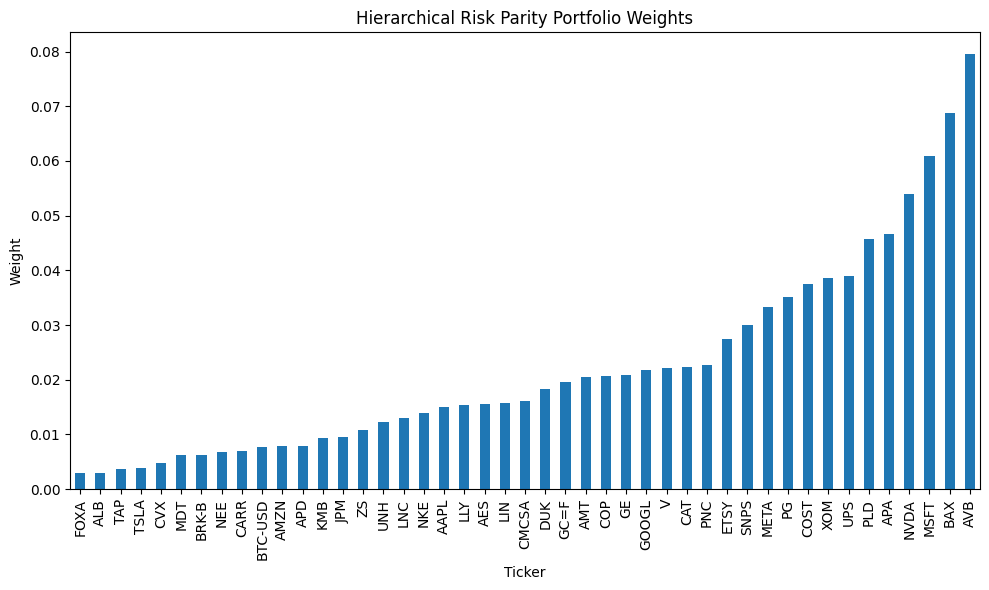

In [28]:
plt.figure(figsize=(10, 6))
w_hrp_final.sort_values().plot(kind='bar')
plt.title('Hierarchical Risk Parity Portfolio Weights')
plt.ylabel('Weight')
plt.xlabel('Ticker')
plt.tight_layout()
plt.show()


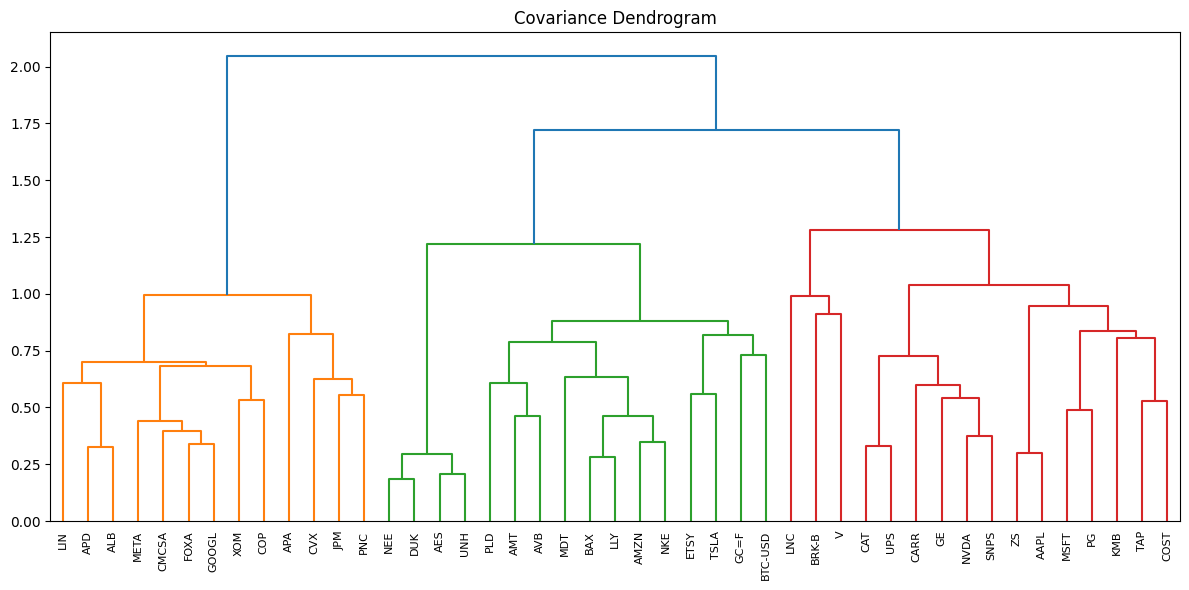

In [29]:
corr_qd = cov2corr(cov_qd)
corr_qd_df = pd.DataFrame(corr_qd, columns=TICKERS, index=TICKERS)

plot_dendrogram(corr_qd_df, 'Covariance Dendrogram')

In [30]:

# ---- stats ------------------------------------------------------
stat_train_hrp = portfolio_stats(w_hrp,  returns_train, rf_daily_train)
stat_test_hrp  = portfolio_stats(w_hrp,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_hrp = pd.concat({'HRP': pd.concat({'Train':stat_train_hrp,
                                         'Test': stat_test_hrp}, axis=1)},
                   axis=1).round(3)
display(stats_hrp)

Portfolio stats:


HRP       
             Train   Test
μ_ann        0.135  0.636
σ_ann        0.157  0.159
Sharpe       0.863  4.004
TotalReturn  0.470  0.054

## HRP Asset Allocation using Shrinkage Covariance

In [31]:

N = len(TICKERS)
corr = np.corrcoef(returns_train.T)
cov = Sigma_shrinkage.values

distance = np.sqrt(0.5 * (1 - corr))  # or np.sqrt(2 * (1-corr)) as in some literature
link = sch.linkage(distance[np.triu_indices(N, 1)], method='ward')



asset_order = getQuasiDiag(link)
cov_qd = cov[np.ix_(asset_order, asset_order)]
tickers_qd = [TICKERS[i] for i in asset_order]




w_hrp_shrinkage = getRecBipart(cov_qd, list(range(len(tickers_qd))))
w_hrp_shrinkage = w_hrp_shrinkage / w_hrp_shrinkage.sum()  # Normalize to 1
w_hrp_shrinkage = w_hrp_shrinkage.values


# Asset order after quasi-diagonalization:
w_hrp_shrinkage_df = pd.Series(w_hrp_shrinkage, index=tickers_qd)
# Reorder to original tickers
w_hrp_shrinkage_final = w_hrp_shrinkage_df.reindex(TICKERS).fillna(0)
print("HRP Weights:\n")
display(w_hrp_shrinkage_final.to_frame())




HRP Weights:



,0
LIN,0.015822
APD,0.008591
ALB,0.003139
META,0.033058
CMCSA,0.016212
FOXA,0.003253
GOOGL,0.022200
XOM,0.038021
COP,0.021655
APA,0.044065


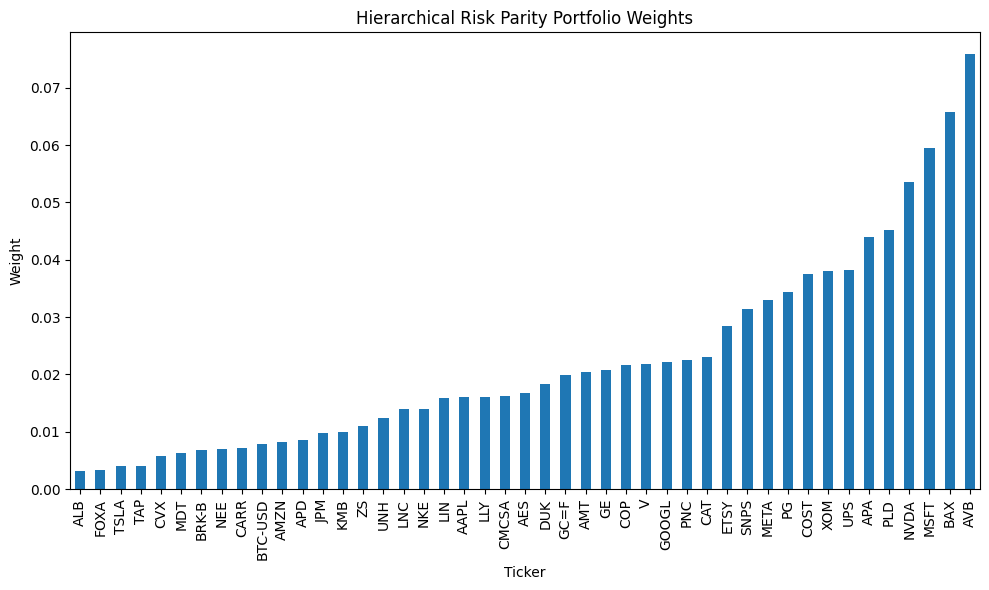

In [32]:

plt.figure(figsize=(10, 6))
w_hrp_shrinkage_final.sort_values().plot(kind='bar')
plt.title('Hierarchical Risk Parity Portfolio Weights')
plt.ylabel('Weight')
plt.xlabel('Ticker')
plt.tight_layout()
plt.show()


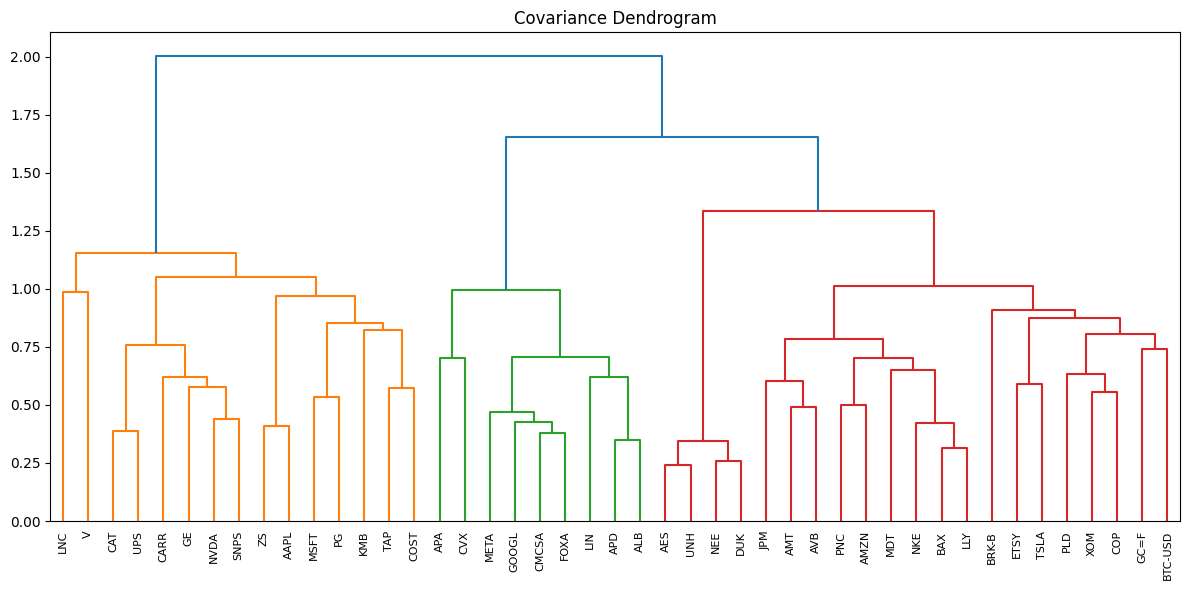

In [33]:
corr_qd = cov2corr(cov_qd)
corr_qd_df = pd.DataFrame(corr_qd, columns=TICKERS, index=TICKERS)

plot_dendrogram(corr_qd_df, 'Covariance Dendrogram')

In [34]:

# ---- stats ------------------------------------------------------
stat_train_hrp_shrinkage = portfolio_stats(w_hrp_shrinkage,  returns_train, rf_daily_train)
stat_test_hrp_shrinkage  = portfolio_stats(w_hrp_shrinkage,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_hrp_shrinkage = pd.concat({'HRP': pd.concat({'Train':stat_train_hrp_shrinkage,
                                         'Test': stat_test_hrp_shrinkage}, axis=1)},
                   axis=1).round(3)
display(stats_hrp_shrinkage)

Portfolio stats:


HRP       
             Train   Test
μ_ann        0.135  0.630
σ_ann        0.156  0.159
Sharpe       0.861  3.965
TotalReturn  0.468  0.054

## HRP Asset Allocation using Denoised Covariance (RMT)

In [35]:
N = len(TICKERS)
corr = corr_denoised
cov = Sigma_denoised
distance = np.sqrt(0.5 * (1 - corr))  # or np.sqrt(2 * (1-corr)) as in some literature
link = sch.linkage(distance[np.triu_indices(N, 1)], method='ward')




asset_order = getQuasiDiag(link)
cov_qd = cov[np.ix_(asset_order, asset_order)]
tickers_qd = [TICKERS[i] for i in asset_order]


w_hrp_denoised = getRecBipart(cov_qd, list(range(len(tickers_qd))))
w_hrp_denoised = w_hrp_denoised / w_hrp_denoised.sum()  # Normalize to 1
w_hrp_denoised = w_hrp_denoised.values


# Asset order after quasi-diagonalization:
w_hrp_denoised_df = pd.Series(w_hrp_denoised, index=tickers_qd)
# Reorder to original tickers
w_hrp_denoised_final = w_hrp_denoised_df.reindex(TICKERS).fillna(0)
print("HRP Weights:\n")
display(w_hrp_denoised_final.to_frame())



HRP Weights:



,0
LIN,0.020548
APD,0.008925
ALB,0.004627
META,0.028282
CMCSA,0.018762
FOXA,0.009300
GOOGL,0.014652
XOM,0.021522
COP,0.018233
APA,0.058815


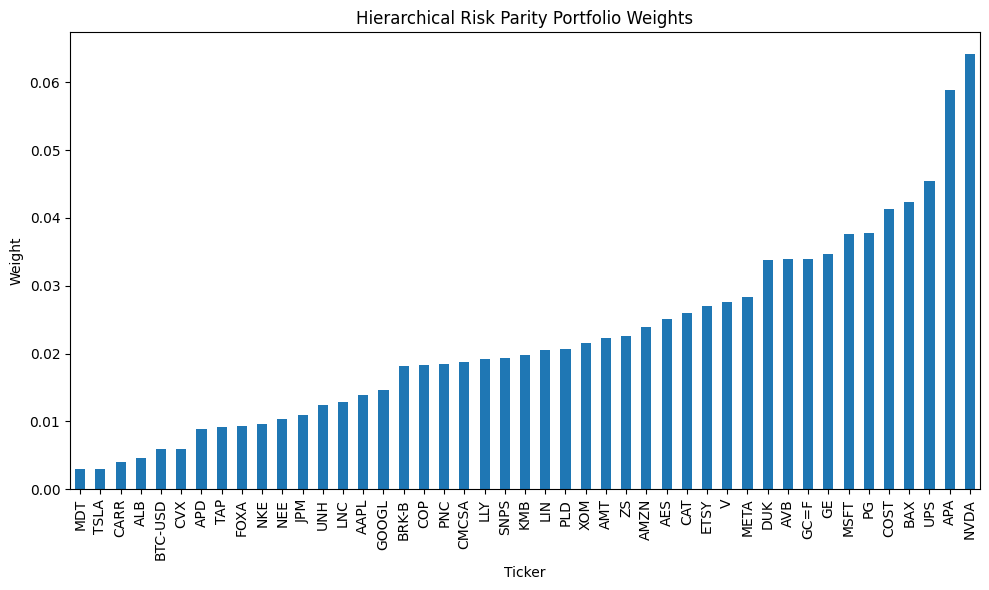

In [36]:

plt.figure(figsize=(10, 6))
w_hrp_denoised_final.sort_values().plot(kind='bar')
plt.title('Hierarchical Risk Parity Portfolio Weights')
plt.ylabel('Weight')
plt.xlabel('Ticker')
plt.tight_layout()
plt.show()


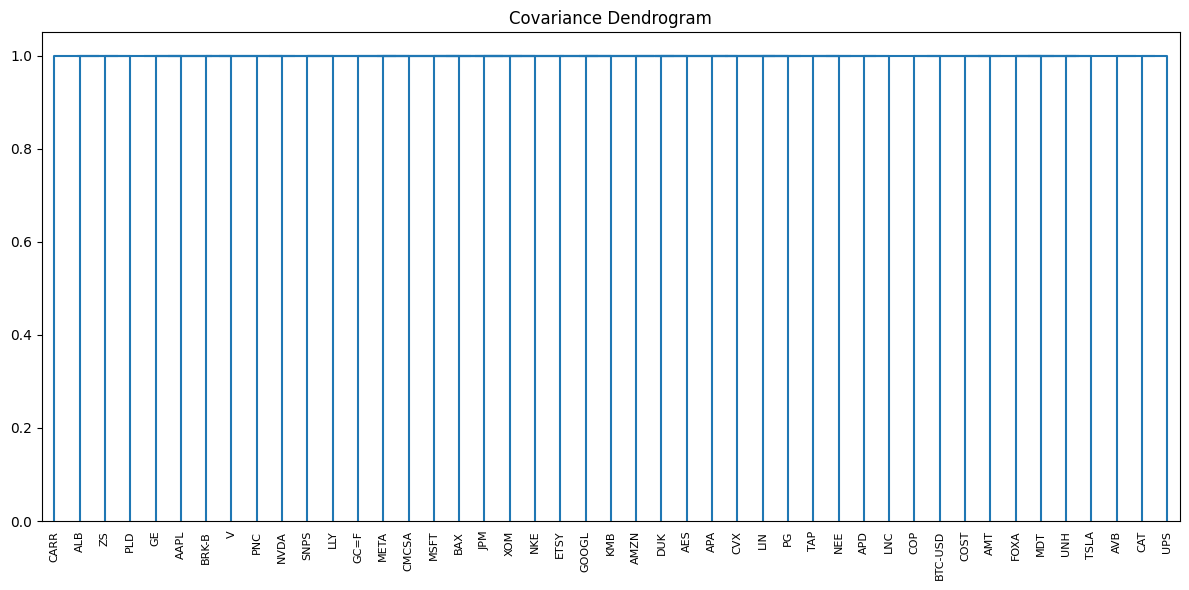

In [37]:

corr_denoised_df = pd.DataFrame(corr_denoised, columns=TICKERS, index=TICKERS)
#corr_denoised_df = (corr_denoised_df + corr_denoised_df.T) / 2

plot_dendrogram(corr_denoised_df, 'Covariance Dendrogram')

In [38]:
# ---- stats ------------------------------------------------------
stat_train_hrp_denoised = portfolio_stats(w_hrp_denoised,  returns_train, rf_daily_train)
stat_test_hrp_denoised  = portfolio_stats(w_hrp_denoised,  returns_test,  rf_daily_test)

print('Portfolio stats:')

stats_hrp_denoised = pd.concat({'HRP': pd.concat({'Train':stat_train_hrp_denoised,
                                         'Test': stat_test_hrp_denoised}, axis=1)},
                   axis=1).round(3)
display(stats_hrp_denoised)

Portfolio stats:


HRP       
             Train   Test
μ_ann        0.016  0.362
σ_ann        0.158  0.164
Sharpe       0.102  2.212
TotalReturn  0.117  0.031

## MVO and Kelly Asset Allocation using Representative of Clusters

In [39]:


N = len(TICKERS)
corr = np.corrcoef(returns_train.T)
cov = Sigma_shrinkage.values

distance = np.sqrt(0.5 * (1 - corr))  # or np.sqrt(2 * (1-corr)) as in some literature
link = sch.linkage(distance[np.triu_indices(N, 1)], method='single')


# Choose the number of clusters, e.g., 8 (you can tune this)
n_clusters = 10
cluster_labels = fcluster(link, n_clusters, criterion='maxclust')

# Map cluster labels to tickers in the quasi-diagonalized order
cluster_map = pd.Series(cluster_labels, index=tickers_qd)


representatives = []
for cluster_id in range(1, n_clusters+1):
    cluster_assets = cluster_map[cluster_map == cluster_id].index.tolist()
    sub_distance = distance[np.ix_([TICKERS.index(tk) for tk in cluster_assets],
                                   [TICKERS.index(tk) for tk in cluster_assets])]
    # Find the medoid
    avg_dist = sub_distance.mean(axis=1)
    medoid_idx = np.argmin(avg_dist)
    representatives.append(cluster_assets[medoid_idx])

print("Cluster representatives:", representatives)


Cluster representatives: ['META', 'TAP', 'GOOGL', 'UPS', 'COST', 'LNC', 'FOXA', 'AMZN', 'NVDA', 'MSFT']


In [40]:
# Subset to representatives
returns_train_sub = returns_train[representatives]
returns_test_sub = returns_test[representatives]
mean_returns_train_sub = mean_returns_train[representatives]
Sigma_train_sub = returns_train_sub.cov()
rf_train = rf_mean_train

# MVO
w_mvo_sub = mvo_weights(mean_returns_train_sub, Sigma_train_sub, rf_train, w_min=w_min, w_max=w_max)
w_mvo_sub = pd.Series(w_mvo_sub, index=representatives)

# Kelly
w_kelly_sub = kelly_long_only_fully_invested(mean_returns_train_sub, Sigma_train_sub, rf_train, w_min=w_min, w_max=w_max)


<Figure size 1000x600 with 0 Axes>

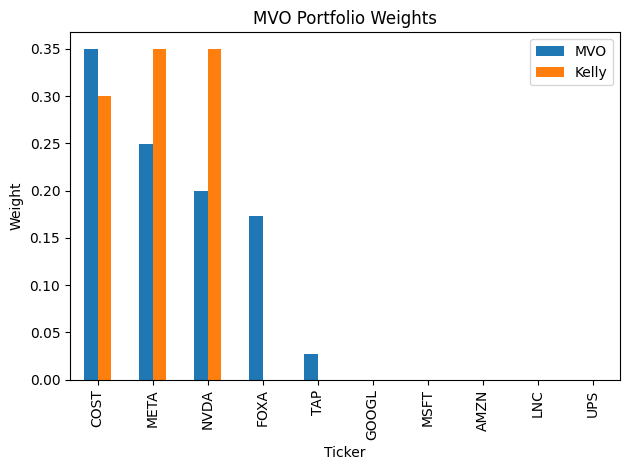

In [41]:
w_mvo_sub_df = pd.DataFrame(w_mvo_sub, index=representatives, columns=['MVO'])
w_kelly_sub_df = pd.DataFrame(w_kelly_sub, index=representatives, columns=['Kelly'])
w_sub_df = pd.concat([w_mvo_sub_df, w_kelly_sub_df], axis=1)

plt.figure(figsize=(10, 6))
w_sub_df.sort_values(by='MVO', ascending=False).plot(kind='bar')
plt.title('MVO Portfolio Weights')
plt.ylabel('Weight')
plt.xlabel('Ticker')
plt.tight_layout()
plt.show()


In [42]:
# Performance
stat_test_mvo_sub = portfolio_stats(w_mvo_sub, returns_test_sub, rf_daily_test)
stat_test_kelly_sub = portfolio_stats(w_kelly_sub, returns_test_sub, rf_daily_test)
display(stat_test_mvo_sub.to_frame(name='MVO'))



,MVO
μ_ann,1.230651
σ_ann,0.195512
Sharpe,6.294507
TotalReturn,0.104203


In [43]:
display(stat_test_kelly_sub.to_frame(name='Kelly'))

,Kelly
μ_ann,1.506525
σ_ann,0.237710
Sharpe,6.337654
TotalReturn,0.127755


# Comparing the Portfolios Performance

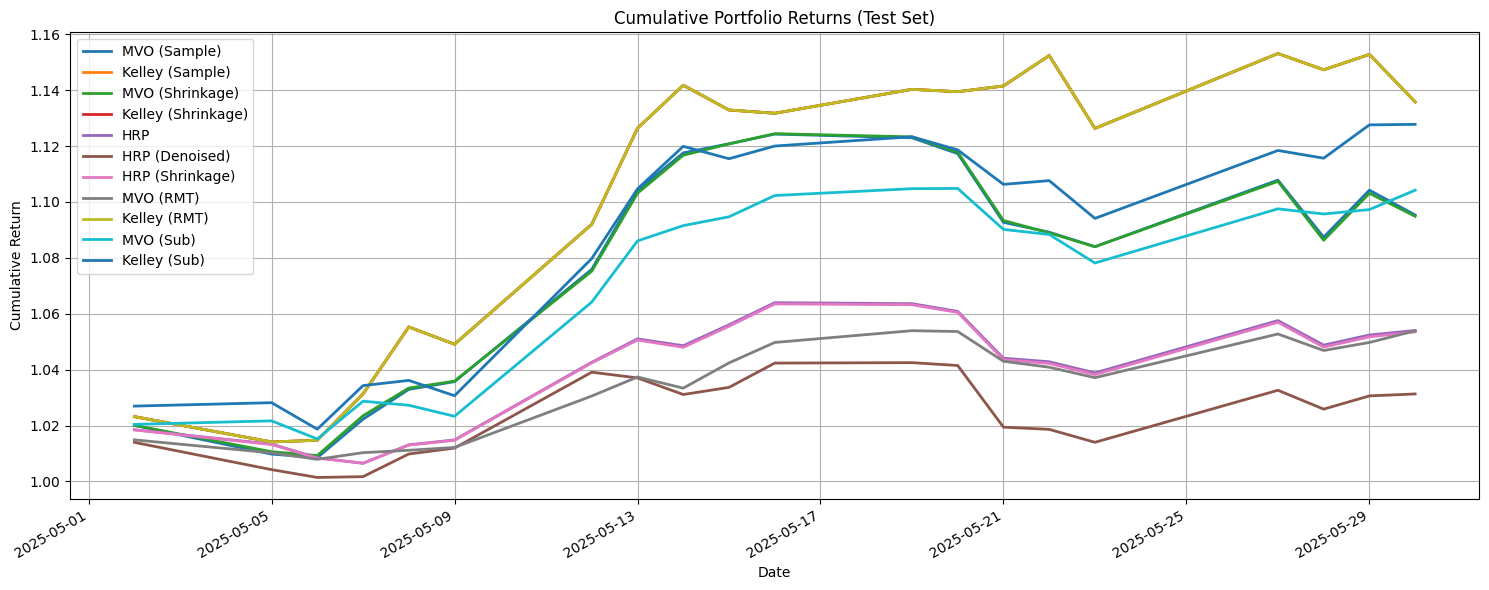

In [44]:
# Align returns for each weight vector (subset columns)
cum_mvo_sample = portfolio_returns(w_mvo_sample, returns_test)
cum_kelly_sample = portfolio_returns(w_kelly_sample, returns_test)

cum_mvo_shrinkage = portfolio_returns(w_mvo_shrinkage, returns_test)
cum_kelly_shrinkage = portfolio_returns(w_kelly_shrinkage, returns_test)

cum_hrp = portfolio_returns(w_hrp, returns_test)


cum_hrp_denoised = portfolio_returns(w_hrp_denoised, returns_test)
cum_hrp_shrinkage = portfolio_returns(w_hrp_shrinkage, returns_test)


cum_mvo_rmt = portfolio_returns(w_mvo_rmt, returns_test)
cum_kelly_rmt = portfolio_returns(w_kelly_rmt, returns_test)

cum_mvo_sub = portfolio_returns(w_mvo_sub, returns_test[representatives])
cum_kelly_sub = portfolio_returns(w_kelly_sub, returns_test[representatives])


# Combine into one DataFrame
cumulative_df = pd.DataFrame({
    'MVO (Sample)': cum_mvo_sample.values.flatten(),
    'Kelley (Sample)': cum_kelly_sample.values.flatten(),
    'MVO (Shrinkage)': cum_mvo_shrinkage.values.flatten(),
    'Kelley (Shrinkage)': cum_kelly_shrinkage.values.flatten(),
    'HRP': cum_hrp.values.flatten(),
    'HRP (Denoised)': cum_hrp_denoised.values.flatten(),
    'HRP (Shrinkage)': cum_hrp_shrinkage.values.flatten(),
    'MVO (RMT)': cum_mvo_rmt.values.flatten(),
    'Kelley (RMT)': cum_kelly_rmt.values.flatten(),
    'MVO (Sub)': cum_mvo_sub.values.flatten(),
    'Kelley (Sub)': cum_kelly_sub.values.flatten()
}, index=returns_test.index)

# Plot cumulative returns
cumulative_df.plot(title="Cumulative Portfolio Returns (Test Set)", lw=2, figsize=(15, 6))
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()


In [45]:
# Compute max drawdowns
dd_mvo_sample = max_drawdown(cum_mvo_sample)
dd_kelly_sample = max_drawdown(cum_kelly_sample)
dd_mvo_shrinkage = max_drawdown(cum_mvo_shrinkage)
dd_kelly_shrinkage = max_drawdown(cum_kelly_shrinkage)
dd_hrp = max_drawdown(cum_hrp)
dd_hrp_denoised = max_drawdown(cum_hrp_denoised)
dd_hrp_shrinkage = max_drawdown(cum_hrp_shrinkage)
dd_mvo_rmt = max_drawdown(cum_mvo_rmt)
dd_kelly_rmt = max_drawdown(cum_kelly_rmt)
dd_mvo_sub = max_drawdown(cum_mvo_sub)
dd_kelly_sub = max_drawdown(cum_kelly_sub)

# Create summary DataFrame
drawdowns = pd.Series({
    'MVO (Sample)': dd_mvo_sample,
    'Kelly (Sample)': dd_kelly_sample,
    'MVO (Shrinkage)': dd_mvo_shrinkage,
    'Kelly (Shrinkage)': dd_kelly_shrinkage,
    'HRP': dd_hrp,
    'HRP (Denoised)': dd_hrp_denoised,
    'HRP (Shrinkage)': dd_hrp_shrinkage,
    'MVO (RMT)': dd_mvo_rmt,
    'Kelly (RMT)': dd_kelly_rmt,
    'MVO (Subset)': dd_mvo_sub,
    'Kelly (Subset)': dd_kelly_sub
}).round(4)

# Convert to % for display
drawdowns_percent = drawdowns * 100
print("📉 Maximum Drawdowns (%):")
print(drawdowns_percent.to_frame("Max Drawdown (%)").sort_values(by='Max Drawdown (%)', ascending=True))


📉 Maximum Drawdowns (%):
                   Max Drawdown (%)
MVO (Shrinkage)               -3.60
MVO (Sample)                  -3.58
HRP (Denoised)                -2.73
Kelly (Subset)                -2.60
MVO (Subset)                  -2.41
HRP (Shrinkage)               -2.38
HRP                           -2.36
Kelly (Sample)                -2.26
Kelly (RMT)                   -2.26
Kelly (Shrinkage)             -2.26
MVO (RMT)                     -1.59


<Figure size 1200x600 with 0 Axes>

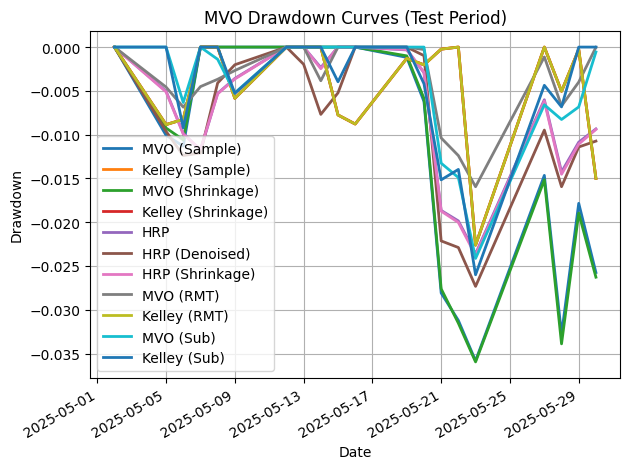

In [46]:
# Compute drawdown curves for each strategy
drawdown_mvo_sample = compute_drawdown_curve(cum_mvo_sample)
drawdown_kelly_sample = compute_drawdown_curve(cum_kelly_sample)
drawdown_mvo_shrinkage = compute_drawdown_curve(cum_mvo_shrinkage)
drawdown_kelly_shrinkage = compute_drawdown_curve(cum_kelly_shrinkage)
drawdown_hrp = compute_drawdown_curve(cum_hrp)
drawdown_hrp_denoised = compute_drawdown_curve(cum_hrp_denoised)
drawdown_hrp_shrinkage = compute_drawdown_curve(cum_hrp_shrinkage)
drawdown_mvo_rmt = compute_drawdown_curve(cum_mvo_rmt)
drawdown_kelly_rmt = compute_drawdown_curve(cum_kelly_rmt)
drawdown_mvo_sub = compute_drawdown_curve(cum_mvo_sub)
drawdown_kelly_sub = compute_drawdown_curve(cum_kelly_sub)

# Combine into one DataFrame
drawdown_df = pd.DataFrame({
    'MVO (Sample)': drawdown_mvo_sample,
    'Kelley (Sample)': drawdown_kelly_sample,
    'MVO (Shrinkage)': drawdown_mvo_shrinkage,
    'Kelley (Shrinkage)': drawdown_kelly_shrinkage,
    'HRP': drawdown_hrp,
    'HRP (Denoised)': drawdown_hrp_denoised,
    'HRP (Shrinkage)': drawdown_hrp_shrinkage,
    'MVO (RMT)': drawdown_mvo_rmt,
    'Kelley (RMT)': drawdown_kelly_rmt,
    'MVO (Sub)': drawdown_mvo_sub,
    'Kelley (Sub)': drawdown_kelly_sub
})

# Plot
plt.figure(figsize=(12, 6))
drawdown_df.plot(title="MVO Drawdown Curves (Test Period)", ylabel="Drawdown", xlabel="Date", lw=2)
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
# Gather all test-stat variables in a dict
stats_dict = {
    "MVO (Sample)": stat_test_mvo_sample,
    "Kelly (Sample)": stat_test_kelly_sample,
    "MVO (Shrinkage)": stat_test_mvo_shrinkage,
    "Kelly (Shrinkage)": stat_test_kelly_shrinkage,
    "MVO (RMT Denoised)": stat_test_mvo_rmt,
    "Kelly (RMT Denoised)": stat_test_kelly_rmt,
    "HRP (Sample)": stat_test_hrp,
    "HRP (Shrinkage)": stat_test_hrp_shrinkage,
    "HRP (RMT Denoised)": stat_test_hrp_denoised,
    "MVO (Sub)": stat_test_mvo_sub,
    "Kelly (Sub)": stat_test_kelly_sub
}

# Build a DataFrame from the test stats
summary_df = pd.DataFrame({name: stats for name, stats in stats_dict.items()}).T

# Add Max Drawdown (from your earlier calculations)
max_drawdowns = {
    "MVO (Sample)": dd_mvo_sample,
    "Kelly (Sample)": dd_kelly_sample,
    "MVO (Shrinkage)": dd_mvo_shrinkage,
    "Kelly (Shrinkage)": dd_kelly_shrinkage,
    "MVO (RMT Denoised)": dd_mvo_rmt,
    "Kelly (RMT Denoised)": dd_kelly_rmt,
    "HRP (Sample)": dd_hrp,
    "HRP (Shrinkage)": dd_hrp_shrinkage,
    "HRP (RMT Denoised)": dd_hrp_denoised,
    "MVO (Sub)": dd_mvo_sub,
    "Kelly (Sub)": dd_kelly_sub
}
summary_df['Max Drawdown (%)'] = pd.Series(max_drawdowns) * 100

# Clean up column names if needed (optional)
summary_df = summary_df.rename(columns={'μ_ann': 'Ann. Return', 'σ_ann': 'Ann. Vol', 'Sharpe': 'Sharpe', 'TotalReturn': 'Total Ret'})

# Format and display
display(summary_df[['Ann. Return', 'Ann. Vol', 'Sharpe', 'Total Ret', 'Max Drawdown (%)']].sort_values(by='Ann. Return', ascending=False).round(3))


,Ann. Return,Ann. Vol,Sharpe,Total Ret,Max Drawdown (%)
Kelly (Sample),1.602,0.258,6.211,0.136,-2.262
Kelly (RMT Denoised),1.602,0.258,6.211,0.136,-2.262
Kelly (Shrinkage),1.602,0.258,6.211,0.136,-2.262
Kelly (Sub),1.507,0.238,6.338,0.128,-2.600
MVO (Sub),1.231,0.196,6.295,0.104,-2.414
MVO (Sample),1.138,0.242,4.710,0.095,-3.583
MVO (Shrinkage),1.132,0.239,4.736,0.095,-3.596
HRP (Sample),0.636,0.159,4.004,0.054,-2.361
HRP (Shrinkage),0.630,0.159,3.965,0.054,-2.378
MVO (RMT Denoised),0.630,0.118,5.348,0.054,-1.595
